In [337]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [338]:
x=pd.read_csv("/content/train.csv")


In [339]:
x.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [340]:
x=x.drop('Id',axis=1)

In [341]:
len(x.columns)

80

In [342]:
l=list(x.isnull().sum())

In [343]:
x.shape

(1460, 80)

In [344]:
x.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [345]:
x.dtypes

,0
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [346]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [347]:
features_with_nan = [i for i in x.columns if x[i].isnull().sum() >= 1]
features_with_nan

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [348]:
(set(x.dtypes.tolist()))

{dtype('int64'), dtype('float64'), dtype('O')}

In [349]:
num_col=x.select_dtypes(include=['float64','int64'])
obj_col=x.select_dtypes(include=['O'])

In [350]:
len(num_col.columns)

37

In [351]:
obj_col.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

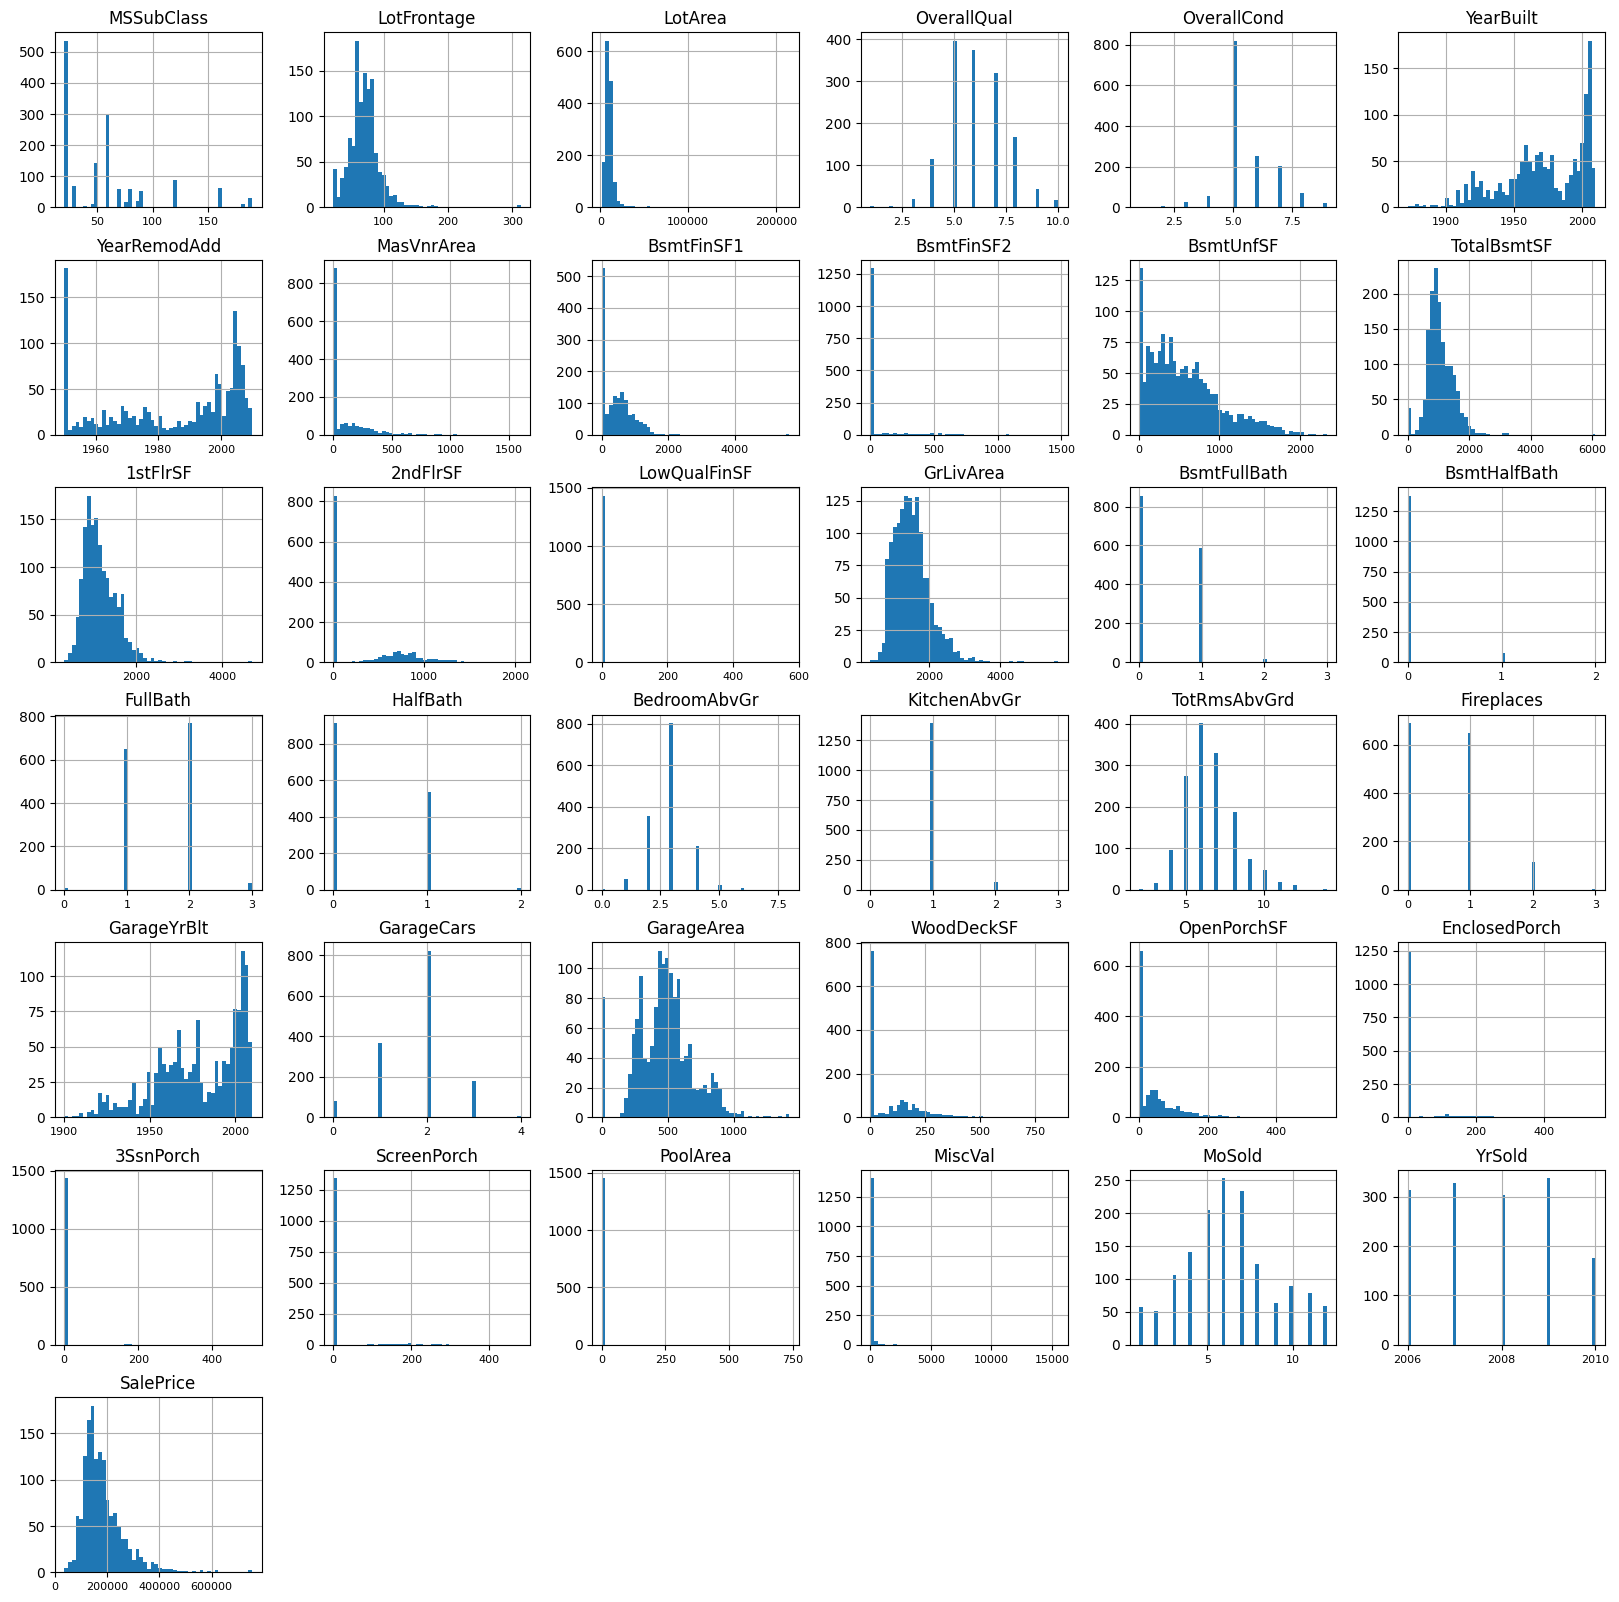

In [352]:
num_col.hist(figsize=(20,20),xlabelsize=8,bins=50)

In [353]:
for col in obj_col.columns:
    print(f"Unique values for {col}: {x[col].value_counts()}")

Unique values for MSZoning: MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
Unique values for Street: Street
Pave    1454
Grvl       6
Name: count, dtype: int64
Unique values for Alley: Alley
Grvl    50
Pave    41
Name: count, dtype: int64
Unique values for LotShape: LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
Unique values for LandContour: LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
Unique values for Utilities: Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
Unique values for LotConfig: LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
Unique values for LandSlope: LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64
Unique values for Neighborhood: Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert 

In [354]:

x['HasPool'] = (
    x['PoolQC']
    .notna()
    .astype(int)
)

x.drop(columns=['PoolQC','Utilities','MiscFeature'], inplace=True)

In [355]:
from sklearn.model_selection import train_test_split
train_df,val_df=train_test_split(x,test_size=0.20,random_state=44)

In [356]:

train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

val_df['SalePrice'] = np.log1p(
    val_df['SalePrice']
)


In [357]:

!pip install tensorflow_decision_forests
import tensorflow_decision_forests as tfdf


In [358]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_df,
    label='SalePrice',
    task=tfdf.keras.Task.REGRESSION
)

val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    val_df,
    label='SalePrice',
    task=tfdf.keras.Task.REGRESSION
)

In [359]:
import tensorflow_decision_forests as tfdf
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


models = {
    "CART Model":
        tfdf.keras.CartModel(task=tfdf.keras.Task.REGRESSION),

    "Random Forest":
        tfdf.keras.RandomForestModel(task=tfdf.keras.Task.REGRESSION),

    "Gradient Boosted Trees":
        tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.REGRESSION)
}

for name, model in models.items():

    print(f" ^^^^^^^^^^^^^^  {name} ^^^^^^^^^^^^^^^^^^^")

    model.fit(train_ds)


    train_pred = (
        model.predict(train_ds)
        .flatten()
    )

    val_pred = (
        model.predict(val_ds)
        .flatten()
    )

    # Actual values
    y_train_true = train_df['SalePrice']
    y_val_true = val_df['SalePrice']

    # Metrics
    train_mae = mean_absolute_error(
        y_train_true,
        train_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train_true,
            train_pred
        )
    )

    train_r2 = r2_score(
        y_train_true,
        train_pred
    )

    val_mae = mean_absolute_error(
        y_val_true,
        val_pred
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_val_true,
            val_pred
        )
    )

    val_r2 = r2_score(
        y_val_true,
        val_pred
    )

    print(name)

    print(
        "Training RMSE:",
        train_rmse
    )

    print(
        "Validation RMSE:",
        val_rmse
    )

    print("**"*50)

Use /tmp/tmprw4csw9i as temporary training directory
Use /tmp/tmp51a421rh as temporary training directory
Use /tmp/tmpgt7sn3ij as temporary training directory
 ^^^^^^^^^^^^^^  CART Model ^^^^^^^^^^^^^^^^^^^
Reading training dataset...
Training dataset read in 0:00:02.166145. Found 1168 examples.
Training model...
Model trained in 0:00:00.344805
Compiling model...
Model compiled.
1/1 [==============================] - 1s 702ms/step
CART Model
Training RMSE: 0.13858656910867592
Validation RMSE: 0.19573039916648644
****************************************************************************************************
 ^^^^^^^^^^^^^^  Random Forest ^^^^^^^^^^^^^^^^^^^
Reading training dataset...
Training dataset read in 0:00:02.130652. Found 1168 examples.
Training model...
Model trained in 0:00:05.987537
Compiling model...
Model compiled.
1/1 [==============================] - 0s 479ms/step
Random Forest
Training RMSE: 0.0735403768008951
Validation RMSE: 0.14471909018114276
*****************

TESTING TEST.CSV

In [360]:
kaggle_df=pd.read_csv('/content/test.csv')

In [361]:
kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [362]:
id=kaggle_df['Id']

In [363]:
type(id)

pandas.core.series.Series

In [364]:
kaggle_df=kaggle_df.drop('Id',axis=1)

In [365]:
kaggle_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [366]:
kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuil

In [367]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [368]:
# ds = tfdf.keras.pd_dataframe_to_tf_dataset(
#     kaggle_df,
#     task=tfdf.keras.Task.REGRESSION
# )

In [369]:

kaggle_df['HasPool'] = (
    kaggle_df['PoolQC']
    .notna()
    .astype(int)
)

columns_to_drop_from_test = ['PoolQC', 'Utilities', 'MiscFeature']
kaggle_df.drop(columns=[col for col in columns_to_drop_from_test if col in kaggle_df.columns], inplace=True)


ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    kaggle_df,
    task=tfdf.keras.Task.REGRESSION
)
model=tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.REGRESSION)
model.fit(train_ds)

pred = (
        model.predict(ds)
        .flatten()
    )

Use /tmp/tmp9rih669t as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.938195. Found 1168 examples.
Training model...
Model trained in 0:00:04.621940
Compiling model...
Model compiled.
2/2 [==============================] - 1s 42ms/step


In [370]:
type(pred)


numpy.ndarray

In [371]:
pred=np.expm1(pred)

In [372]:
pred

array([118301.9  , 163050.83 , 186380.42 , ..., 153736.62 , 111599.375,
       193136.34 ], dtype=float32)

In [373]:
predictions_df = pd.DataFrame({'Id': id, 'SalePrice': pred})
display(predictions_df.head())

,Id,SalePrice
0,1461,118301.898438
1,1462,163050.828125
2,1463,186380.421875
3,1464,184251.531250
4,1465,197266.328125


In [374]:
type(predictions_df)

pandas.core.frame.DataFrame

In [375]:
predictions_df.columns

Index(['Id', 'SalePrice'], dtype='object')

In [376]:
predictions_df.to_csv('output.csv',index=False)

In [377]:
f=pd.read_csv('/content/output.csv')

In [378]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB
